In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

data_path = '/content/drive/MyDrive/synthea_payer/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
members = pd.read_csv(data_path + 'risk_stratification_data.csv')

print(f"Members loaded: {len(members):,}")
print(f"\nRisk tier distribution:")
print(members.risk_tier.value_counts())
print(f"\nTotal cost range: ${members['total_cost'].min():,.0f} - ${members['total_cost'].max():,.0f}")

Members loaded: 50,000

Risk tier distribution:
risk_tier
TIER 1 - High Risk        12500
TIER 2 - Elevated Risk    12500
TIER 3 - Moderate Risk    12500
Tier 4 - Low Risk         12500
Name: count, dtype: int64

Total cost range: $438 - $5,613,453


# Cost Distribution Visualization

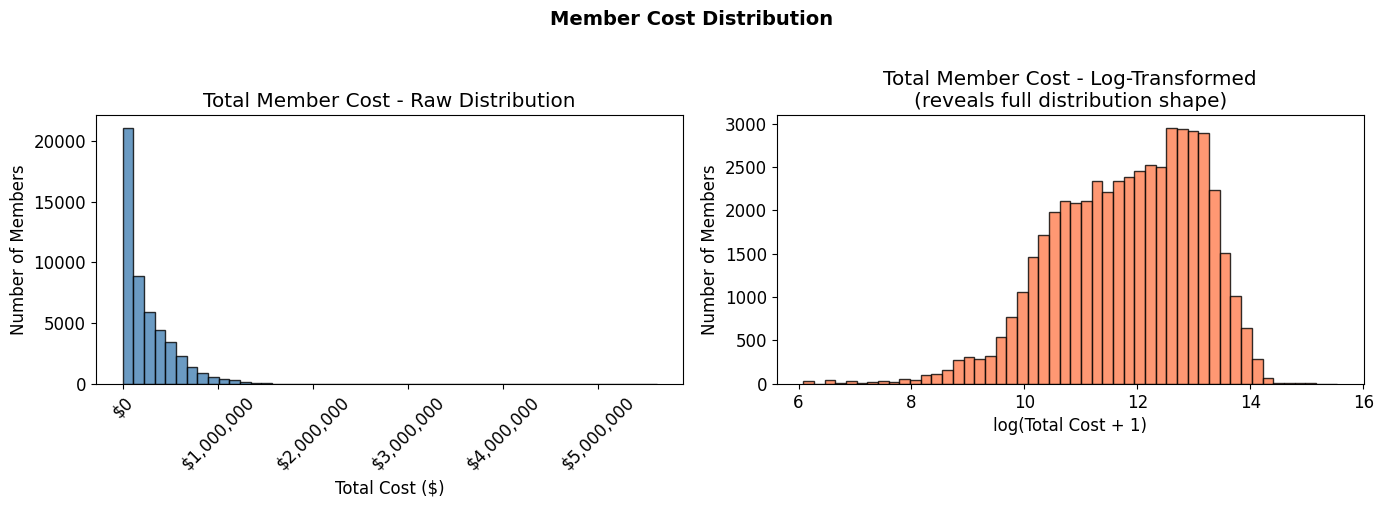

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(members['total_cost'], bins=50,
             color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title("Total Member Cost - Raw Distribution")
axes[0].set_xlabel("Total Cost ($)")
axes[0].set_ylabel("Number of Members")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
axes[0].tick_params(axis='x', labelrotation=45)


# Log-transformed
axes[1].hist(np.log1p(members['total_cost']), bins=50,
             color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title("Total Member Cost - Log-Transformed\n(reveals full distribution shape)")
axes[1].set_xlabel('log(Total Cost + 1)')
axes[1].set_ylabel("Number of Members")

plt.suptitle('Member Cost Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cost_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



Synthea can generate patients with extremely long lifespans and chronic conditions, resulting in thousands of prescription dispense rows per patient and unrealistically high lifetime medication costs. Members with total prescription costs exceeding $500,000 were excluded from the analysis as statistical outliers driven by Synthea's simulation mechanics rather than clinically meaningful variation

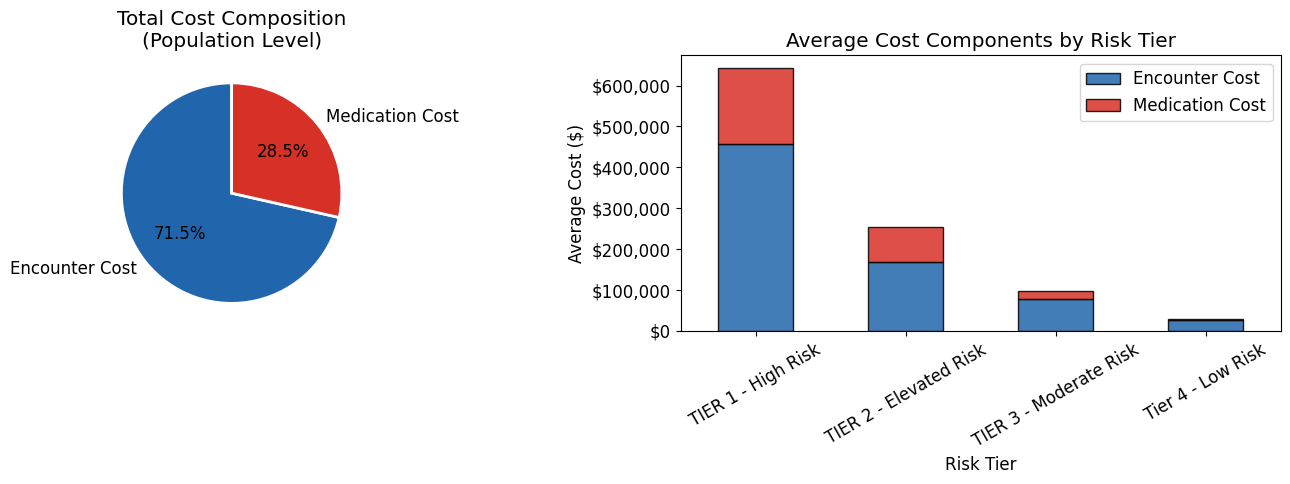

In [68]:
cost_components = members[['total_encounter_costs', 'total_prescription_cost']].sum()
labels = ['Encounter Cost', 'Medication Cost']
colors = ['#2166ac', '#d73027']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(cost_components, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Total Cost Composition\n(Population Level)')

# Stacked bar by risk tier
tier_components = members.groupby('risk_tier')[[
    'total_encounter_costs', 'total_prescription_cost']
].mean().reset_index()

tier_components.set_index('risk_tier')[
    ['total_encounter_costs', 'total_prescription_cost']
].plot(kind='bar', stacked=True, ax=axes[1],
       color=colors, edgecolor='black', alpha=0.85)

axes[1].set_title('Average Cost Components by Risk Tier')
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('Average Cost ($)')
axes[1].tick_params(axis='x', labelrotation=30)
axes[1].legend(['Encounter Cost', 'Medication Cost'])
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.tight_layout()
plt.savefig('cost_composition.png', dpi=150, bbox_inches='tight')
plt.show()

In [69]:
for ttier_summary = members.groupby('risk_tier').agg(
    member_count=('patient_id', 'count'),
    avg_total_cost=('total_cost', 'mean'),
    total_cost=('total_cost', 'sum'),
    avg_emergency=('emergency_count', 'mean'),
    avg_inpatient=('inpatient_count', 'mean'),
    avg_wellness=('wellness_count', 'mean'),
    avg_prescription=('prescription_count', 'mean'),
).round(2)

tier_summary['pct_of_total_cost'] = (
    tier_summary['total_cost'] / tier_summary['total_cost'].sum() * 100
).round(1)

tier_summary = tier_summary.sort_values('avg_total_cost', ascending=False)
print(tier_summary.to_string())

                        member_count  avg_total_cost       total_cost  avg_emergency  avg_inpatient  avg_wellness  avg_prescription  pct_of_total_cost
risk_tier                                                                                                                                             
TIER 1 - High Risk             12500      641,874.45 8,023,430,661.63           4.57           1.10         12.34             65.48              62.80
TIER 2 - Elevated Risk         12500      253,744.77 3,171,809,575.27           2.15           0.89         13.00             25.39              24.80
TIER 3 - Moderate Risk         12500       96,997.29 1,212,466,101.71           1.44           0.52         12.77             14.94               9.50
Tier 4 - Low Risk              12500       29,554.75   369,434,326.59           0.58           0.07         10.15              4.13               2.90


# Cost Concentration - The Lorenz Curve

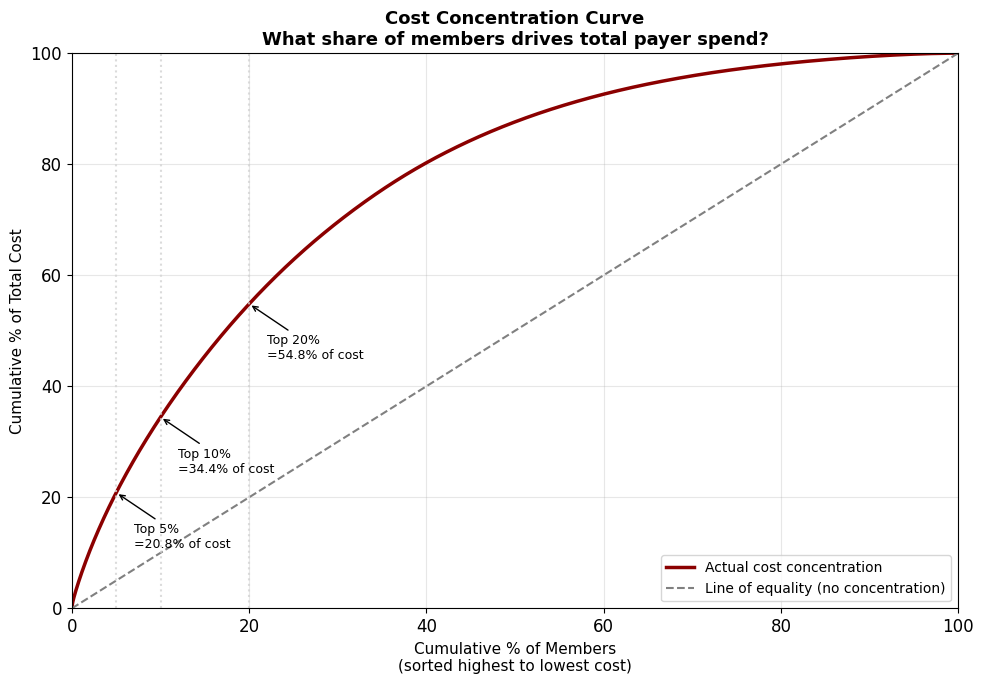

In [70]:
members_sorted = members.sort_values('total_cost', ascending=False).reset_index(drop=True)
members_sorted['cumulative_cost'] = members_sorted['total_cost'].cumsum()
members_sorted['cumulative_cost_pct'] = (
    members_sorted['cumulative_cost'] / members_sorted['total_cost'].sum() * 100
)
members_sorted['member_pct'] = (members_sorted.index + 1) / len(members_sorted) * 100

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    members_sorted['member_pct'],
    members_sorted['cumulative_cost_pct'],
    color='darkred', linewidth=2.5,
    label='Actual cost concentration'
)

# Line of perfect equality (45-degree line)
ax.plot([0, 100], [0, 100], color='gray', linestyle='--',
        linewidth=1.5, label='Line of equality (no concentration)')

# Reference Lines
for pct in [5, 10, 20]:
  cost_at_pct = members_sorted[
      members_sorted['member_pct'] <= pct
  ]['cumulative_cost_pct'].max()
  ax.axvline(x=pct, color='lightgray', linestyle=':', alpha=0.8)
  ax.annotate(
      f'Top {pct}%\n={cost_at_pct:.1f}% of cost',
      xy=(pct, cost_at_pct),
      xytext=(pct + 2, cost_at_pct - 10),
      fontsize=9,
      arrowprops=dict(arrowstyle='->', color='black', lw=1)
  )

  ax.set_xlabel('Cumulative % of Members\n(sorted highest to lowest cost)', fontsize=11)
  ax.set_ylabel('Cumulative % of Total Cost', fontsize=11)
  ax.set_title('Cost Concentration Curve\nWhat share of members drives total payer spend?',
               fontsize=13, fontweight='bold')
  ax.legend(fontsize=10)
  ax.grid(True, alpha=0.3)
  ax.set_xlim(0, 100)
  ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('cost_concentration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

I found that the top 10% of members drove 34% of total payer cost. This concentration justifies prioritizing care management resources toward the highest-cost tier, where targeted interventions have the greatest potential cost impact.

In [71]:
thresholds = [1, 5, 10, 20, 50]

print("=== Cost Concentration Summary ===\n")
for pct in thresholds:
  n = int(len(members_sorted) * pct / 100)
  cost_share = members_sorted.head(n)['total_cost'].sum() / members_sorted['total_cost'].sum()
  print(f"Top {pct:>3}% of members ({n:,} members) account for {cost_share:.1f}")

=== Cost Concentration Summary ===

Top   1% of members (500 members) account for 0.1
Top   5% of members (2,500 members) account for 0.2
Top  10% of members (5,000 members) account for 0.3
Top  20% of members (10,000 members) account for 0.5
Top  50% of members (25,000 members) account for 0.9


# Risk Tier Utilization Profiling

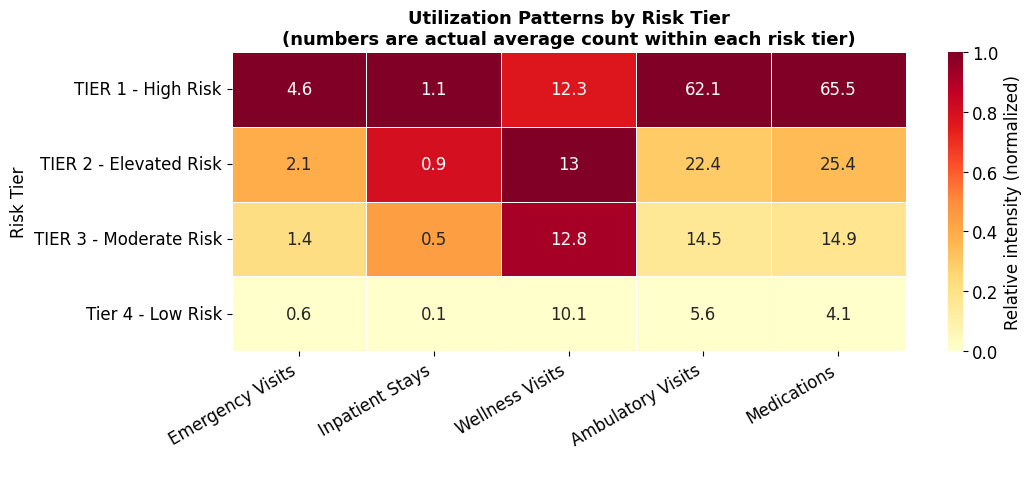

In [72]:
util_cols = {
    'emergency_count': 'Emergency Visits',
    'inpatient_count': 'Inpatient Stays',
    'wellness_count': 'Wellness Visits',
    'ambulatory_count': 'Ambulatory Visits',
    'prescription_count': 'Medications'
}

tier_util = members.groupby('risk_tier')[list(util_cols.keys())].mean()
tier_util = tier_util.rename(columns=util_cols)

# Normalize each column to 0-1 so all metrics are on the same scale visually
tier_util_norm = (tier_util - tier_util.min()) / (tier_util.max() - tier_util.min())

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    tier_util_norm,
    annot=tier_util.round(1),
    fmt='g',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Relative intensity (normalized)'}
)
ax.set_title('Utilization Patterns by Risk Tier\n(numbers are actual average count within each risk tier)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(' ')
ax.set_ylabel('Risk Tier')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('utilization_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

All utilization counts reflect lifetime totals per member, as Synthea generates complete patient histories from birth. Tier 1 members show consistently higher lifetime utilization across all care settings.

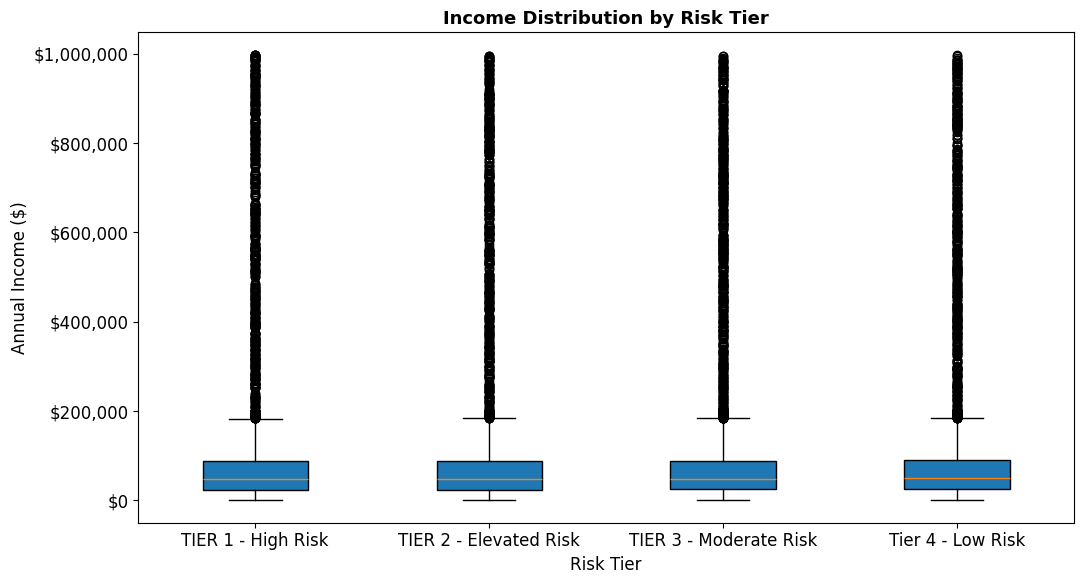

In [73]:
# Income distribution across tiers

fig, ax = plt.subplots(figsize=(11, 6))

tier_order = ['TIER 1 - High Risk', 'TIER 2 - Elevated Risk',
              'TIER 3 - Moderate Risk', 'Tier 4 - Low Risk']

data_by_tier = [
    members[members['risk_tier'] == tier]['INCOME'].dropna()
    for tier in tier_order
]

ax.boxplot(data_by_tier, labels=tier_order,
           patch_artist=True)
ax.set_title('Income Distribution by Risk Tier', fontsize=13, fontweight='bold')
ax.set_xlabel('Risk Tier')
ax.set_ylabel('Annual Income ($)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
plt.tight_layout()
plt.savefig('income_by_risk_rier.png', dpi=150, bbox_inches='tight')
plt.show()

Income was evenly distributed across all four risk tiers. High-cost members were not disproportionately low-income. Cost concentration appears to be driven by clinical complexity, not socioeconomic status.

In [78]:
for tier in tier_order:
  subset = members[members['risk_tier'] == tier]
  total = subset['total_cost'].sum()
  prescription = subset['total_prescription_cost'].sum()
  encounter = subset['total_encounter_costs'].sum()
  print(f"{tier}")
  print(f" Prescription % of total cost: {prescription / total:.1%}")
  print(f" Encounter % of total cost: {encounter / total:.1%}")
  print()

TIER 1 - High Risk
 Prescription % of total cost: 28.8%
 Encounter % of total cost: 71.2%

TIER 2 - Elevated Risk
 Prescription % of total cost: 33.5%
 Encounter % of total cost: 66.5%

TIER 3 - Moderate Risk
 Prescription % of total cost: 20.3%
 Encounter % of total cost: 79.7%

Tier 4 - Low Risk
 Prescription % of total cost: 7.2%
 Encounter % of total cost: 92.8%



# Summary & Conclusions

**Key Kindings**


*   After excluding prescription outliers, total member costs ranged from $438 to $5,613,453
*   The top 5% of members account for 20.8% of total payer costs, and the top 10% account for 34.4%
*   Tier 1 members averaged $641,874 in lifetime cost, which is 21x the Tier 4 average, with 4.6 emergency visits and 1.1 inpatient stays per member.
*   Medication costs made up 28.8% of Tier 1 spend compared to 7.2% in Tier 4. Chronic disease management is most likely the key cost driver.

**Business Implications**


*   Cost is heavily concentrated at the top. Care management resources should be prioritized.
*   Emergency utilization in Tier 1 is more than 2X the population average. A targeted urgent care redirection program could reduce avoidable emergency spend.




